# Predição de deterioração clínica em 6 horas

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/flavioluizseixas/aprendizado-de-maquina-para-saude/blob/main/notebooks/Encontro_05/analise_deterioracao_6h.ipynb)

Este notebook usa os 30 registros da atividade para:

1. descrever os principais atributos, excluindo ID, alvo e saídas do modelo fictício;
2. avaliar `Probabilidade` e `Alerta` em relação a `Deteriorou_6h`;
3. separar treino e teste e transformar os dados com imputação sem vazamento;
4. comparar regressão logística, árvore, random forest, XGBoost e outros classificadores.

> **Limitação central:** são apenas 30 pacientes. As métricas são demonstrativas,
> muito instáveis e não validam uso clínico. A Unidade B está sub-representada e
> concentra dados ausentes de SpO₂.

## 1. Configuração e leitura dos dados

In [1]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from scipy.stats import norm
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    accuracy_score,
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_curve,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

try:
    from xgboost import XGBClassifier
except ImportError as exc:
    raise ImportError(
        "XGBoost é necessário nesta atividade. Instale-o com: pip install xgboost"
    ) from exc

RANDOM_STATE = 42
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", None)
warnings.filterwarnings("ignore", category=FutureWarning)

In [2]:
DATA_FILENAME = "dados_deterioracao_6h.csv"
data_candidates = [
    Path(DATA_FILENAME),
    Path("PRD") / "atividades_informática_saúde" / DATA_FILENAME,
]
DATA_PATH = next((path for path in data_candidates if path.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError(f"Arquivo não encontrado. Caminhos testados: {data_candidates}")

df = pd.read_csv(DATA_PATH, encoding="utf-8-sig")
display(df.head())
print(f"Dimensões: {df.shape[0]} pacientes x {df.shape[1]} colunas")
print(f"Arquivo: {DATA_PATH.resolve()}")

,ID,Unidade,Idade,Sexo,FR,SpO2,PAS,O2_mais_30min,Probabilidade,Alerta,Deteriorou_6h
0,1,A,58,M,18,96.0,128,N,0.08,N,N
1,2,A,66,M,20,95.0,122,N,0.12,N,N
2,3,A,74,F,22,94.0,118,N,0.21,N,N
3,4,A,79,M,30,89.0,88,S,0.82,S,S
4,5,A,63,M,26,91.0,104,S,0.55,S,N


Dimensões: 30 pacientes x 11 colunas
Arquivo: C:\Users\flavio\Dev\aprendizado-de-maquina-para-saude\PRD\atividades_informática_saúde\dados_deterioracao_6h.csv


In [3]:
expected_columns = {
    "ID", "Unidade", "Idade", "Sexo", "FR", "SpO2", "PAS",
    "O2_mais_30min", "Probabilidade", "Alerta", "Deteriorou_6h",
}
assert set(df.columns) == expected_columns
assert df["ID"].is_unique and len(df) == 30
assert df["Probabilidade"].between(0, 1).all()
assert set(df["Alerta"]) <= {"S", "N"}
assert set(df["Deteriorou_6h"]) <= {"S", "N"}

quality = pd.DataFrame({
    "tipo": df.dtypes.astype(str),
    "ausentes_n": df.isna().sum(),
    "ausentes_%": 100 * df.isna().mean(),
    "valores_unicos": df.nunique(dropna=True),
})
display(quality.round(1))

,tipo,ausentes_n,ausentes_%,valores_unicos
ID,int64,0,0.0,30
Unidade,object,0,0.0,2
Idade,int64,0,0.0,30
Sexo,object,0,0.0,2
FR,int64,0,0.0,17
SpO2,float64,7,23.3,12
PAS,int64,0,0.0,24
O2_mais_30min,object,0,0.0,2
Probabilidade,float64,0,0.0,30
Alerta,object,0,0.0,2


## 2. Estatística descritiva dos atributos

A descrição abaixo exclui deliberadamente:

- `ID`, que é apenas um identificador;
- `Deteriorou_6h`, que é o rótulo alvo;
- `Probabilidade` e `Alerta`, que são saídas do modelo fictício.

`O2_mais_30min` é descrito para auditoria, mas será excluído do treinamento porque
ocorre depois de T0 e causaria *data leakage*.

In [4]:
numeric_attributes = ["Idade", "FR", "SpO2", "PAS"]
categorical_attributes = ["Unidade", "Sexo", "O2_mais_30min"]
descriptive_attributes = numeric_attributes + categorical_attributes

numeric_summary = df[numeric_attributes].describe().T.rename(columns={
    "count": "n_válido", "mean": "média", "std": "desvio_padrão",
    "min": "mínimo", "25%": "Q1", "50%": "mediana", "75%": "Q3", "max": "máximo",
})
numeric_summary.insert(1, "ausentes_n", df[numeric_attributes].isna().sum())
numeric_summary.insert(2, "ausentes_%", 100 * df[numeric_attributes].isna().mean())
display(numeric_summary.round(2))

,n_válido,ausentes_n,ausentes_%,média,desvio_padrão,mínimo,Q1,mediana,Q3,máximo
Idade,30.0,0,0.00,67.20,11.29,45.0,59.25,68.5,76.75,85.0
FR,30.0,0,0.00,24.13,4.92,17.0,20.00,23.5,28.75,33.0
SpO2,23.0,7,23.33,92.96,3.27,87.0,90.00,94.0,95.50,98.0
PAS,30.0,0,0.00,108.87,15.91,84.0,92.50,111.0,121.50,134.0


In [5]:
categorical_summary = pd.concat(
    [
        df[column]
        .fillna("Ausente")
        .value_counts(dropna=False)
        .rename_axis("categoria")
        .reset_index(name="n")
        .assign(atributo=column)
        for column in categorical_attributes
    ],
    ignore_index=True,
)
categorical_summary["percentual"] = (
    100 * categorical_summary["n"] / categorical_summary.groupby("atributo")["n"].transform("sum")
)
display(categorical_summary[["atributo", "categoria", "n", "percentual"]].round(1))

,atributo,categoria,n,percentual
0,Unidade,A,22,73.3
1,Unidade,B,8,26.7
2,Sexo,M,23,76.7
3,Sexo,F,7,23.3
4,O2_mais_30min,N,19,63.3
5,O2_mais_30min,S,11,36.7


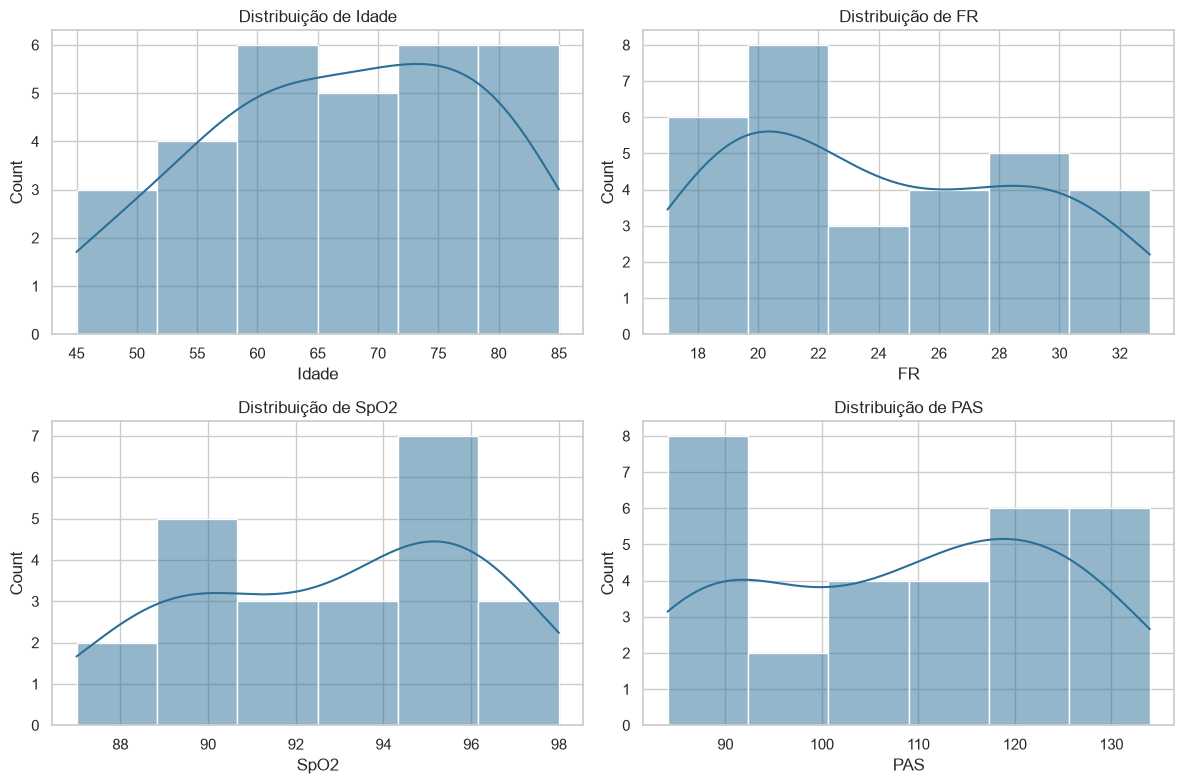

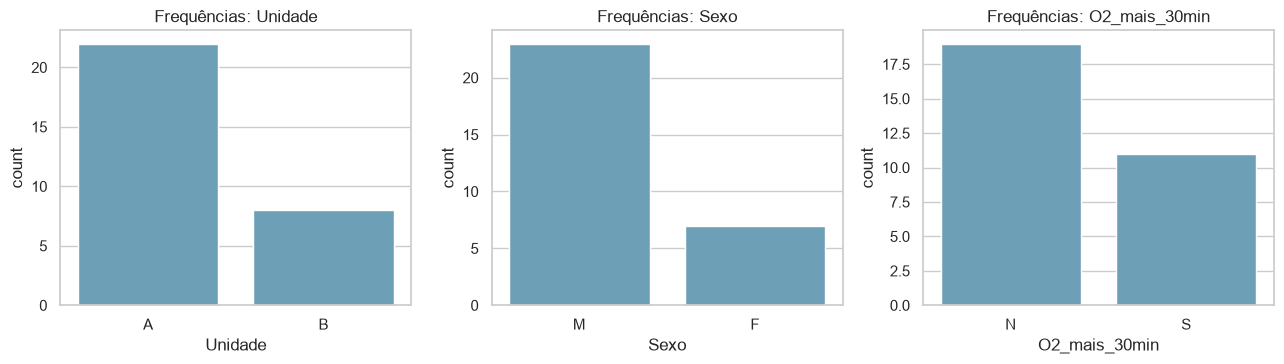

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for column, axis in zip(numeric_attributes, axes.flat):
    sns.histplot(df[column], kde=True, ax=axis, color="#2A6F97")
    axis.set_title(f"Distribuição de {column}")
fig.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
for column, axis in zip(categorical_attributes, axes):
    sns.countplot(data=df, x=column, ax=axis, color="#61A5C2")
    axis.set_title(f"Frequências: {column}")
fig.tight_layout()
plt.show()

In [7]:
spo2_missing_by_unit = pd.crosstab(
    df["Unidade"],
    df["SpO2"].isna().map({False: "Registrada", True: "Ausente"}),
    margins=True,
)
display(spo2_missing_by_unit)

spo2_missing_rate = (
    df.assign(SpO2_ausente=df["SpO2"].isna())
    .groupby("Unidade")["SpO2_ausente"]
    .agg(["sum", "count", "mean"])
    .rename(columns={"sum": "ausentes", "count": "n", "mean": "proporção_ausente"})
)
spo2_missing_rate["percentual_ausente"] = 100 * spo2_missing_rate["proporção_ausente"]
display(spo2_missing_rate.round(3))

SpO2,Ausente,Registrada,All
Unidade,,,
A,1,21,22
B,6,2,8
All,7,23,30


,ausentes,n,proporção_ausente,percentual_ausente
Unidade,,,,
A,1,22,0.045,4.545
B,6,8,0.750,75.000


## 3. Desempenho do modelo preditivo fictício

O desfecho positivo é deterioração em até 6 horas (`S = 1`).
O alerta da tabela corresponde ao limiar de 40%: probabilidade maior ou igual a
0,40 gera alerta. A matriz segue a convenção `[[VN, FP], [FN, VP]]`.

Na curva ROC, a linha contínua usa suavização de kernel apenas para facilitar a
leitura. Os pontos mostram a ROC empírica, e o AUC é calculado diretamente das
probabilidades observadas, sem suavização.

In [8]:
y_true_fict = df["Deteriorou_6h"].map({"N": 0, "S": 1}).astype(int)
y_pred_fict = df["Alerta"].map({"N": 0, "S": 1}).astype(int)
y_prob_fict = df["Probabilidade"].astype(float)
ALERT_THRESHOLD = 0.40

assert np.array_equal(y_pred_fict, (y_prob_fict >= ALERT_THRESHOLD).astype(int))

tn, fp, fn, tp = confusion_matrix(y_true_fict, y_pred_fict, labels=[0, 1]).ravel()
specificity = tn / (tn + fp)
npv = tn / (tn + fn)

fictitious_metrics = pd.Series({
    "Acurácia": accuracy_score(y_true_fict, y_pred_fict),
    "Acurácia balanceada": balanced_accuracy_score(y_true_fict, y_pred_fict),
    "Sensibilidade (recall)": recall_score(y_true_fict, y_pred_fict),
    "Especificidade": specificity,
    "Precisão (PPV)": precision_score(y_true_fict, y_pred_fict),
    "Valor preditivo negativo": npv,
    "F1": f1_score(y_true_fict, y_pred_fict),
    "ROC AUC (probabilidade)": roc_auc_score(y_true_fict, y_prob_fict),
}, name="valor")

print(f"VN={tn}, FP={fp}, FN={fn}, VP={tp}")
display(fictitious_metrics.to_frame().round(3))

VN=17, FP=4, FN=2, VP=7


,valor
Acurácia,0.800
Acurácia balanceada,0.794
Sensibilidade (recall),0.778
Especificidade,0.810
Precisão (PPV),0.636
Valor preditivo negativo,0.895
F1,0.700
ROC AUC (probabilidade),0.958


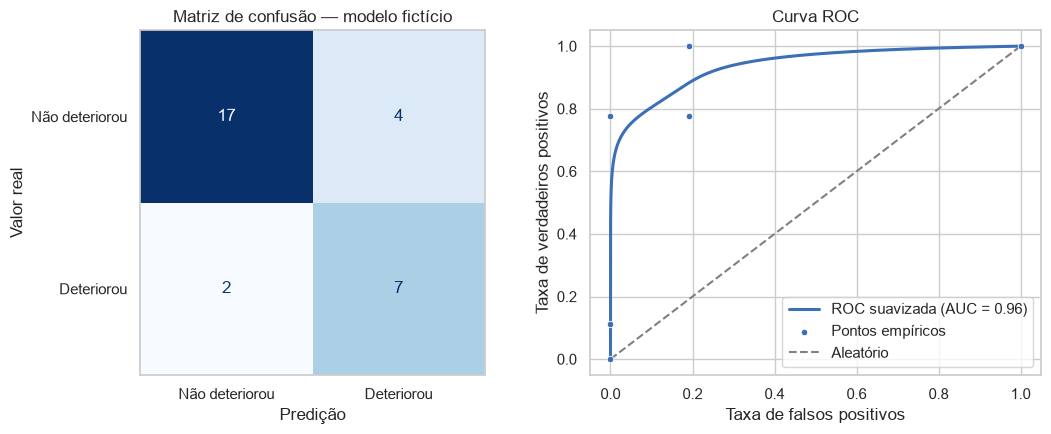

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
ConfusionMatrixDisplay.from_predictions(
    y_true_fict,
    y_pred_fict,
    labels=[0, 1],
    display_labels=["Não deteriorou", "Deteriorou"],
    cmap="Blues",
    colorbar=False,
    ax=axes[0],
)
axes[0].set_title("Matriz de confusão — modelo fictício")
axes[0].set_xlabel("Predição")
axes[0].set_ylabel("Valor real")
axes[0].grid(False)

fpr_fict, tpr_fict, _ = roc_curve(y_true_fict, y_prob_fict)
negative_scores = y_prob_fict[y_true_fict == 0].to_numpy()
positive_scores = y_prob_fict[y_true_fict == 1].to_numpy()

def kernel_bandwidth(scores: np.ndarray) -> float:
    # Regra de Silverman com piso para evitar uma curva quase discreta.
    return max(1.06 * scores.std(ddof=1) * len(scores) ** (-1 / 5), 0.02)

negative_bandwidth = kernel_bandwidth(negative_scores)
positive_bandwidth = kernel_bandwidth(positive_scores)
bandwidth_margin = 4 * max(negative_bandwidth, positive_bandwidth)
smooth_thresholds = np.linspace(
    y_prob_fict.max() + bandwidth_margin,
    y_prob_fict.min() - bandwidth_margin,
    400,
)
smooth_fpr = norm.sf(
    (smooth_thresholds[:, None] - negative_scores) / negative_bandwidth
).mean(axis=1)
smooth_tpr = norm.sf(
    (smooth_thresholds[:, None] - positive_scores) / positive_bandwidth
).mean(axis=1)
smooth_fpr = np.r_[0, smooth_fpr, 1]
smooth_tpr = np.r_[0, smooth_tpr, 1]

axes[1].plot(
    smooth_fpr,
    smooth_tpr,
    color="#3B6FB6",
    linewidth=2.2,
    label=f"ROC suavizada (AUC = {roc_auc_score(y_true_fict, y_prob_fict):.2f})",
)
axes[1].scatter(
    fpr_fict,
    tpr_fict,
    s=22,
    color="#3B6FB6",
    edgecolor="white",
    linewidth=0.6,
    zorder=3,
    label="Pontos empíricos",
)
axes[1].plot([0, 1], [0, 1], "--", color="gray", label="Aleatório")
axes[1].set_title("Curva ROC")
axes[1].set_xlabel("Taxa de falsos positivos")
axes[1].set_ylabel("Taxa de verdadeiros positivos")
axes[1].legend(loc="lower right")
fig.tight_layout()
plt.show()

In [10]:
def subgroup_metrics(group: pd.DataFrame) -> pd.Series:
    y_true = group["Deteriorou_6h"].map({"N": 0, "S": 1}).astype(int)
    y_pred = group["Alerta"].map({"N": 0, "S": 1}).astype(int)
    matrix = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn_g, fp_g, fn_g, tp_g = matrix.ravel()
    return pd.Series({
        "n": len(group),
        "deteriorações": y_true.sum(),
        "acurácia": accuracy_score(y_true, y_pred),
        "sensibilidade": tp_g / (tp_g + fn_g) if (tp_g + fn_g) else np.nan,
        "especificidade": tn_g / (tn_g + fp_g) if (tn_g + fp_g) else np.nan,
        "FP": fp_g,
        "FN": fn_g,
    })

performance_by_unit = pd.DataFrame({
    unit: subgroup_metrics(group)
    for unit, group in df.groupby("Unidade")
}).T
performance_by_unit.index.name = "Unidade"
display(performance_by_unit.round(3))

,n,deteriorações,acurácia,sensibilidade,especificidade,FP,FN
Unidade,,,,,,,
A,22.0,6.0,0.864,1.000,0.812,3.0,0.0
B,8.0,3.0,0.625,0.333,0.800,1.0,2.0


Os dois falsos negativos estão na Unidade B. Assim, a média global esconde
uma diferença operacional relevante entre serviços. O ROC AUC mede ordenação das
probabilidades em todos os limiares; ele não substitui a análise do limiar clínico,
da calibração nem das consequências de falsos negativos.

## 4. Divisão treino/teste e transformação

Para uma predição em T0, entram apenas `Unidade`, `Idade`, `Sexo`, `FR`,
`SpO2` e `PAS`. Excluímos:

- `ID`: identificador;
- `Probabilidade` e `Alerta`: saídas do modelo que queremos avaliar, não preditores;
- `Deteriorou_6h`: alvo;
- `O2_mais_30min`: conduta posterior a T0, portanto vazamento de dados.

A separação é estratificada. Imputação, codificação e padronização são ajustadas
somente no treino por meio de um `Pipeline`.

In [11]:
numeric_features = ["Idade", "FR", "SpO2", "PAS"]
categorical_features = ["Unidade", "Sexo"]
model_features = numeric_features + categorical_features

X = df[model_features].copy()
y = df["Deteriorou_6h"].map({"N": 0, "S": 1}).astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    stratify=y,
    random_state=RANDOM_STATE,
)

split_summary = pd.DataFrame({
    "n": [len(y_train), len(y_test)],
    "positivos": [y_train.sum(), y_test.sum()],
    "prevalência": [y_train.mean(), y_test.mean()],
}, index=["treino", "teste"])
display(split_summary.round(3))
print("SpO2 ausente — treino:", X_train["SpO2"].isna().sum())
print("SpO2 ausente — teste:", X_test["SpO2"].isna().sum())

,n,positivos,prevalência
treino,21,6,0.286
teste,9,3,0.333


SpO2 ausente — treino: 6
SpO2 ausente — teste: 1


In [12]:
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
    ("scaler", StandardScaler()),
])
categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("one_hot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

preprocessor = ColumnTransformer([
    ("numeric", numeric_transformer, numeric_features),
    ("categorical", categorical_transformer, categorical_features),
], verbose_feature_names_out=False)

# Demonstração: fit apenas no treino; o teste recebe somente transform().
X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed = preprocessor.transform(X_test)
transformed_names = preprocessor.get_feature_names_out()

display(pd.DataFrame(
    X_train_transformed,
    columns=transformed_names,
    index=X_train.index,
).head().round(3))
print("Treino transformado:", X_train_transformed.shape)
print("Teste transformado:", X_test_transformed.shape)
print("Mediana de SpO2 aprendida no treino:", preprocessor.named_transformers_["numeric"]
      .named_steps["imputer"].statistics_[numeric_features.index("SpO2")])

,Idade,FR,SpO2,PAS,missingindicator_SpO2,Unidade_A,Unidade_B,Sexo_F,Sexo_M
23,1.035,1.171,-1.383,-1.185,-0.632,0.0,1.0,0.0,1.0
24,0.396,0.581,0.286,-0.460,1.581,0.0,1.0,1.0,0.0
7,-1.979,-0.993,1.621,0.989,-0.632,1.0,0.0,1.0,0.0
0,-0.792,-1.189,0.953,1.110,-0.632,1.0,0.0,0.0,1.0
18,-0.700,-0.796,0.620,0.506,-0.632,1.0,0.0,0.0,1.0


Treino transformado: (21, 9)
Teste transformado: (9, 9)
Mediana de SpO2 aprendida no treino: 94.0


## 5. Comparação dos modelos

A escolha é feita pela média do ROC AUC em validação cruzada estratificada
apenas no treino. O teste permanece reservado para uma avaliação final. Incluímos
modelos lineares, baseados em árvores, vizinhança e margem.

Com amostra tão pequena, três folds ainda produzem estimativas muito variáveis;
esta etapa ensina o fluxo, não demonstra superioridade de algoritmo.

In [13]:
models = {
    "Regressão logística": LogisticRegression(
        max_iter=2_000, class_weight="balanced", random_state=RANDOM_STATE
    ),
    "Árvore de decisão": DecisionTreeClassifier(
        max_depth=3, min_samples_leaf=2, class_weight="balanced", random_state=RANDOM_STATE
    ),
    "Random forest": RandomForestClassifier(
        n_estimators=300, max_depth=4, min_samples_leaf=2,
        class_weight="balanced_subsample", random_state=RANDOM_STATE, n_jobs=-1,
    ),
    "XGBoost": XGBClassifier(
        n_estimators=120, max_depth=2, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        eval_metric="logloss", random_state=RANDOM_STATE, n_jobs=1,
    ),
    "K-vizinhos": KNeighborsClassifier(n_neighbors=5),
    "SVM radial": SVC(
        kernel="rbf", probability=True, class_weight="balanced", random_state=RANDOM_STATE
    ),
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
scoring = {
    "roc_auc": "roc_auc",
    "acuracia": "accuracy",
    "acuracia_balanceada": "balanced_accuracy",
    "sensibilidade": "recall",
}

pipelines = {}
cv_rows = []
for name, estimator in models.items():
    pipeline = Pipeline([
        ("preprocess", clone(preprocessor)),
        ("model", estimator),
    ])
    scores = cross_validate(
        pipeline, X_train, y_train, cv=cv, scoring=scoring,
        return_train_score=False, error_score="raise",
    )
    pipelines[name] = pipeline
    cv_rows.append({
        "Modelo": name,
        "ROC AUC médio": scores["test_roc_auc"].mean(),
        "ROC AUC desvio": scores["test_roc_auc"].std(ddof=1),
        "Acurácia média": scores["test_acuracia"].mean(),
        "Acurácia balanceada média": scores["test_acuracia_balanceada"].mean(),
        "Sensibilidade média": scores["test_sensibilidade"].mean(),
    })

cv_results = (
    pd.DataFrame(cv_rows)
    .set_index("Modelo")
    .sort_values("ROC AUC médio", ascending=False)
)
display(cv_results.round(3))

,ROC AUC médio,ROC AUC desvio,Acurácia média,Acurácia balanceada média,Sensibilidade média
Modelo,,,,,
Regressão logística,1.000,0.000,1.000,1.000,1.000
Random forest,1.000,0.000,1.000,1.000,1.000
K-vizinhos,1.000,0.000,1.000,1.000,1.000
XGBoost,1.000,0.000,1.000,1.000,1.000
SVM radial,0.967,0.058,0.952,0.917,0.833
Árvore de decisão,0.917,0.144,0.952,0.917,0.833


In [14]:
test_rows = []
test_predictions = {}

for name, pipeline in pipelines.items():
    pipeline.fit(X_train, y_train)
    probability = pipeline.predict_proba(X_test)[:, 1]
    prediction = (probability >= 0.50).astype(int)
    tn_m, fp_m, fn_m, tp_m = confusion_matrix(y_test, prediction, labels=[0, 1]).ravel()
    test_predictions[name] = {"probability": probability, "prediction": prediction}
    test_rows.append({
        "Modelo": name,
        "ROC AUC": roc_auc_score(y_test, probability),
        "Acurácia": accuracy_score(y_test, prediction),
        "Acurácia balanceada": balanced_accuracy_score(y_test, prediction),
        "Sensibilidade": recall_score(y_test, prediction, zero_division=0),
        "Especificidade": tn_m / (tn_m + fp_m) if (tn_m + fp_m) else np.nan,
        "Precisão": precision_score(y_test, prediction, zero_division=0),
        "F1": f1_score(y_test, prediction, zero_division=0),
        "FN": fn_m,
        "FP": fp_m,
    })

test_results = (
    pd.DataFrame(test_rows)
    .set_index("Modelo")
    .loc[cv_results.index]
)
display(test_results.round(3))

,ROC AUC,Acurácia,Acurácia balanceada,Sensibilidade,Especificidade,Precisão,F1,FN,FP
Modelo,,,,,,,,,
Regressão logística,1.0,1.000,1.000,1.000,1.0,1.0,1.0,0,0
Random forest,1.0,1.000,1.000,1.000,1.0,1.0,1.0,0,0
K-vizinhos,1.0,0.889,0.833,0.667,1.0,1.0,0.8,1,0
XGBoost,1.0,1.000,1.000,1.000,1.0,1.0,1.0,0,0
SVM radial,1.0,1.000,1.000,1.000,1.0,1.0,1.0,0,0
Árvore de decisão,1.0,1.000,1.000,1.000,1.0,1.0,1.0,0,0


Modelo selecionado pelo ROC AUC médio na validação cruzada: Regressão logística


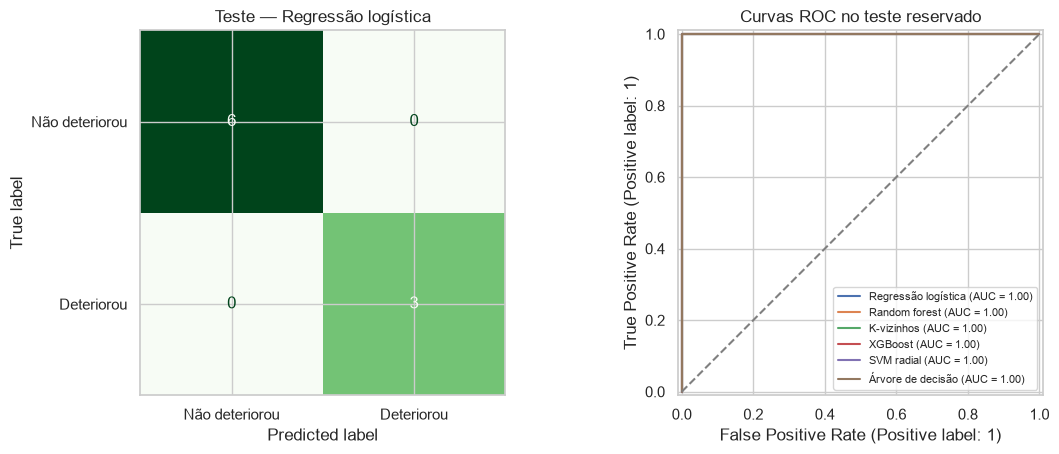

In [15]:
best_model_name = cv_results["ROC AUC médio"].idxmax()
best_model = pipelines[best_model_name]
best_prediction = test_predictions[best_model_name]["prediction"]

print(f"Modelo selecionado pelo ROC AUC médio na validação cruzada: {best_model_name}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.7))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    best_prediction,
    labels=[0, 1],
    display_labels=["Não deteriorou", "Deteriorou"],
    cmap="Greens",
    colorbar=False,
    ax=axes[0],
)
axes[0].set_title(f"Teste — {best_model_name}")

for name in cv_results.index:
    RocCurveDisplay.from_predictions(
        y_test,
        test_predictions[name]["probability"],
        name=name,
        ax=axes[1],
    )
axes[1].plot([0, 1], [0, 1], "--", color="gray")
axes[1].set_title("Curvas ROC no teste reservado")
axes[1].legend(fontsize=8, loc="lower right")
fig.tight_layout()
plt.show()

## 6. Interpretação e próximos passos

- A seleção acima respeita a separação do teste, mas **não é conclusiva** com 30 casos.
- Resultados perfeitos ou muito altos nesta base pequena devem aumentar a cautela com
  overfitting, instabilidade do split e possível efeito do processo assistencial.
- A ausência de SpO₂ é concentrada na Unidade B; imputar permite executar o modelo,
  mas não resolve o viés do processo de registro.
- Antes de qualquer uso real: ampliar e tornar a amostra representativa, fazer validação
  externa e temporal, avaliar calibração, intervalos de incerteza e desempenho por unidade,
  justificar o limiar e testar prospectivamente o fluxo clínico.
- Uma saída `SEM ALERTA` não deve diminuir a prioridade de uma avaliação clínica sem
  evidência de segurança e governança apropriada.